# Sales Lead Conversion & Segmentation Intelligence

**Author:** Nitin Prasad

**Notebook:** 02_Lead_Conversion_Segmentation

### Purpose

Build and evaluate machine learning models to predict the probability that a sales lead will convert, and save the final classification pipeline for Streamlit deployment.

**Input:** `cleaned_leads.csv`

**Output:** Classification model, evaluation metrics & model artifacts

**Models:** Logistic Regression, Decision Tree, Random Forest, Gradient Boost, XG Boost


## 1. Import Libraries and Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

print("Classification notebook setup completed.")

Classification notebook setup completed.


## 2. Load the Clean Dataset

In [2]:
file_path = Path("../Dataset/cleaned_leads.csv")

df = pd.read_csv(file_path)

print("Cleaned dataset loaded successfully.")

Cleaned dataset loaded successfully.


### 2.1 Basic Dataset Check

Verify the dimensions of the cleaned dataset and confirm that the target variable is available.

In [3]:
print(f"Dataset shape: {df.shape}")
print(f"Target column present: {'Converted' in df.columns}")

Dataset shape: (19269, 28)
Target column present: True


### 2.2 Target Distribution

Review the distribution of the `Converted` target variable to confirm the class balance before model training.

In [4]:
df["Converted"].value_counts(normalize=True).mul(100).round(2)

Converted
0   60.75
1   39.25
Name: proportion, dtype: float64

## 3. Feature Selection

### 3.1 Define Features and Target

Separate the target variable `Converted` from the predictive features.

In [5]:
X = df.drop(columns="Converted")
y = df["Converted"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (19269, 27)
Target shape: (19269,)


### 3.2 Select Modeling Features

Remove identifier and raw date fields that are not directly used as predictive features.

- `Lead_ID` is an identifier and should not influence predictions.
- `Lead_Date` will be excluded in its raw datetime form. It was used for temporal validation and EDA, but the raw date is not required for the current classification model.

In [6]:
drop_columns = ["Lead_ID", "Lead_Date"]

X = X.drop(columns=drop_columns)

print("Removed columns:", drop_columns)
print("Remaining features:", X.shape[1])

Removed columns: ['Lead_ID', 'Lead_Date']
Remaining features: 25


In [7]:
X.columns.tolist()

['Industry',
 'State',
 'Employee_Count',
 'Lead_Source',
 'Campaign_Type',
 'Sales_Rep_Interactions',
 'Previous_Interactions',
 'Days_Since_Last_Interaction',
 'Website_Visits',
 'Pages_Viewed',
 'Email_Opens',
 'Email_Clicks',
 'Content_Downloads',
 'Demo_Attended',
 'Estimated_Budget',
 'Estimated_Deal_Value',
 'Decision_Maker',
 'Contact_Requests',
 'Product_Page_Visits',
 'Trial_Started',
 'Company_Size',
 'Total_Interactions',
 'Digital_Engagement_Score',
 'Budget_per_Employee',
 'Deal_to_Budget_Ratio']

## 4. Separate Numerical and Categorical Features

Separate the predictive variables into numerical and categorical groups.

This allows different preprocessing strategies to be applied to each feature type within the machine learning pipeline.

In [8]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Employee_Count', 'Sales_Rep_Interactions', 'Previous_Interactions', 'Days_Since_Last_Interaction', 'Website_Visits', 'Pages_Viewed', 'Email_Opens', 'Email_Clicks', 'Content_Downloads', 'Estimated_Budget', 'Estimated_Deal_Value', 'Contact_Requests', 'Product_Page_Visits', 'Total_Interactions', 'Digital_Engagement_Score', 'Budget_per_Employee', 'Deal_to_Budget_Ratio']

Categorical features:
['Industry', 'State', 'Lead_Source', 'Campaign_Type', 'Demo_Attended', 'Decision_Maker', 'Trial_Started', 'Company_Size']


In [9]:
print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 17
Number of categorical features: 8


## 5. Train-Test Split

Split the dataset into training and testing sets while preserving the proportion of converted and non-converted leads.

The training set will be used for model development and cross-validation, while the test set will remain untouched until final model evaluation.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [11]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (15415, 25)
Testing set: (3854, 25)


In [12]:
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Training target distribution:
Converted
0   60.75
1   39.25
Name: proportion, dtype: float64

Testing target distribution:
Converted
0   60.74
1   39.26
Name: proportion, dtype: float64


## 6. Build the Preprocessing Pipeline

Create a common preprocessing structure for numerical and categorical features.

- Numerical features: median imputation followed by standardization.
- Categorical features: most-frequent imputation followed by one-hot encoding.
- Unknown categories in future data will be handled safely using `handle_unknown="ignore"`.

The preprocessing component will later be combined with each classification model inside its own pipeline.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [14]:
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

In [15]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessor, numerical_features),
    ("categorical", categorical_preprocessor, categorical_features)
])

## 7. Import Classification Models

Import the classification algorithms selected for model comparison.

The models represent different modeling approaches, allowing us to evaluate which algorithm performs best for lead conversion prediction.

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

## 8. Logistic Regression Pipeline

Create a Logistic Regression pipeline by combining the common preprocessing component with a Logistic Regression classifier.

Logistic Regression will serve as the baseline classification model for lead conversion prediction.

In [17]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

In [18]:
logistic_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 9. Decision Tree Pipeline

Create a Decision Tree classification pipeline using the common preprocessing component.

The Decision Tree provides a nonlinear and interpretable model for comparison with Logistic Regression.

In [19]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

In [20]:
decision_tree_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 10. Random Forest Pipeline

Create a Random Forest classification pipeline using the common preprocessing component.

Random Forest will be evaluated against the baseline models to determine whether a tree-based ensemble can better capture the patterns associated with lead conversion.

In [21]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

In [22]:
random_forest_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 11. Gradient Boosting Pipeline

Create a Gradient Boosting classification pipeline using the common preprocessing component.

Gradient Boosting builds an ensemble of weak learners sequentially and can capture nonlinear relationships that may not be captured by simpler models.

In [23]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

In [24]:
gradient_boosting_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 12. XGBoost Pipeline

Create an XGBoost classification pipeline using the common preprocessing component.

XGBoost will be evaluated alongside the other classification models to determine whether its performance provides an advantage for lead conversion prediction.

In [25]:
from xgboost import XGBClassifier

xgboost_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=RANDOM_STATE,
        eval_metric="logloss"
    ))
])

In [26]:
xgboost_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 13. Stratified Cross-Validation Setup

Use Stratified 5-Fold Cross-Validation to compare the classification pipelines using the training data.

The models will be evaluated using multiple metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

The test set will remain untouched until the final model is selected.

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

## 14. Cross-Validate Logistic Regression

Evaluate the Logistic Regression pipeline using Stratified 5-Fold Cross-Validation on the training data.

The mean and standard deviation of each evaluation metric will be calculated across the five folds.

In [28]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [29]:
logistic_results = {
    "Accuracy": logistic_cv["test_accuracy"].mean(),
    "Precision": logistic_cv["test_precision"].mean(),
    "Recall": logistic_cv["test_recall"].mean(),
    "F1-Score": logistic_cv["test_f1"].mean(),
    "ROC-AUC": logistic_cv["test_roc_auc"].mean()
}

pd.Series(logistic_results).round(4)

Accuracy    0.74
Precision   0.71
Recall      0.56
F1-Score    0.63
ROC-AUC     0.79
dtype: float64

In [30]:
logistic_std = {
    "Accuracy": logistic_cv["test_accuracy"].std(),
    "Precision": logistic_cv["test_precision"].std(),
    "Recall": logistic_cv["test_recall"].std(),
    "F1-Score": logistic_cv["test_f1"].std(),
    "ROC-AUC": logistic_cv["test_roc_auc"].std()
}

pd.Series(logistic_std).round(4)

Accuracy    0.01
Precision   0.01
Recall      0.01
F1-Score    0.01
ROC-AUC     0.01
dtype: float64

## 15. Cross-Validate Decision Tree

Evaluate the Decision Tree pipeline using Stratified 5-Fold Cross-Validation on the training data.

The same evaluation metrics used for Logistic Regression will be calculated for comparison.

In [31]:
decision_tree_cv = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [32]:
decision_tree_results = {
    "Accuracy": decision_tree_cv["test_accuracy"].mean(),
    "Precision": decision_tree_cv["test_precision"].mean(),
    "Recall": decision_tree_cv["test_recall"].mean(),
    "F1-Score": decision_tree_cv["test_f1"].mean(),
    "ROC-AUC": decision_tree_cv["test_roc_auc"].mean()
}

pd.Series(decision_tree_results).round(4)

Accuracy    0.64
Precision   0.54
Recall      0.55
F1-Score    0.54
ROC-AUC     0.62
dtype: float64

In [33]:
decision_tree_std = {
    "Accuracy": decision_tree_cv["test_accuracy"].std(),
    "Precision": decision_tree_cv["test_precision"].std(),
    "Recall": decision_tree_cv["test_recall"].std(),
    "F1-Score": decision_tree_cv["test_f1"].std(),
    "ROC-AUC": decision_tree_cv["test_roc_auc"].std()
}

pd.Series(decision_tree_std).round(4)

Accuracy    0.01
Precision   0.01
Recall      0.02
F1-Score    0.01
ROC-AUC     0.01
dtype: float64

## 16. Cross-Validate Random Forest

Evaluate the Random Forest pipeline using Stratified 5-Fold Cross-Validation on the training data.

The same evaluation metrics used for the previous models will be calculated to ensure a fair comparison.

In [34]:
random_forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [35]:
random_forest_results = {
    "Accuracy": random_forest_cv["test_accuracy"].mean(),
    "Precision": random_forest_cv["test_precision"].mean(),
    "Recall": random_forest_cv["test_recall"].mean(),
    "F1-Score": random_forest_cv["test_f1"].mean(),
    "ROC-AUC": random_forest_cv["test_roc_auc"].mean()
}

pd.Series(random_forest_results).round(4)

Accuracy    0.73
Precision   0.69
Recall      0.57
F1-Score    0.63
ROC-AUC     0.78
dtype: float64

In [36]:
random_forest_std = {
    "Accuracy": random_forest_cv["test_accuracy"].std(),
    "Precision": random_forest_cv["test_precision"].std(),
    "Recall": random_forest_cv["test_recall"].std(),
    "F1-Score": random_forest_cv["test_f1"].std(),
    "ROC-AUC": random_forest_cv["test_roc_auc"].std()
}

pd.Series(random_forest_std).round(4)

Accuracy    0.01
Precision   0.01
Recall      0.01
F1-Score    0.01
ROC-AUC     0.01
dtype: float64

## 17. Cross-Validate Gradient Boosting

Evaluate the Gradient Boosting pipeline using Stratified 5-Fold Cross-Validation on the training data.

The same evaluation metrics will be used to maintain a consistent comparison across all classification models.

In [37]:
gradient_boosting_cv = cross_validate(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [38]:
gradient_boosting_results = {
    "Accuracy": gradient_boosting_cv["test_accuracy"].mean(),
    "Precision": gradient_boosting_cv["test_precision"].mean(),
    "Recall": gradient_boosting_cv["test_recall"].mean(),
    "F1-Score": gradient_boosting_cv["test_f1"].mean(),
    "ROC-AUC": gradient_boosting_cv["test_roc_auc"].mean()
}

pd.Series(gradient_boosting_results).round(4)

Accuracy    0.74
Precision   0.71
Recall      0.57
F1-Score    0.63
ROC-AUC     0.79
dtype: float64

In [39]:
gradient_boosting_std = {
    "Accuracy": gradient_boosting_cv["test_accuracy"].std(),
    "Precision": gradient_boosting_cv["test_precision"].std(),
    "Recall": gradient_boosting_cv["test_recall"].std(),
    "F1-Score": gradient_boosting_cv["test_f1"].std(),
    "ROC-AUC": gradient_boosting_cv["test_roc_auc"].std()
}

pd.Series(gradient_boosting_std).round(4)

Accuracy    0.01
Precision   0.01
Recall      0.01
F1-Score    0.01
ROC-AUC     0.01
dtype: float64

## 18. Cross-Validate XGBoost

Evaluate the XGBoost pipeline using Stratified 5-Fold Cross-Validation on the training data.

The same evaluation metrics will be used so that XGBoost can be compared fairly with the other classification models.

In [40]:
xgboost_cv = cross_validate(
    xgboost_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [41]:
xgboost_results = {
    "Accuracy": xgboost_cv["test_accuracy"].mean(),
    "Precision": xgboost_cv["test_precision"].mean(),
    "Recall": xgboost_cv["test_recall"].mean(),
    "F1-Score": xgboost_cv["test_f1"].mean(),
    "ROC-AUC": xgboost_cv["test_roc_auc"].mean()
}

pd.Series(xgboost_results).round(4)

Accuracy    0.73
Precision   0.69
Recall      0.58
F1-Score    0.63
ROC-AUC     0.78
dtype: float64

In [42]:
xgboost_std = {
    "Accuracy": xgboost_cv["test_accuracy"].std(),
    "Precision": xgboost_cv["test_precision"].std(),
    "Recall": xgboost_cv["test_recall"].std(),
    "F1-Score": xgboost_cv["test_f1"].std(),
    "ROC-AUC": xgboost_cv["test_roc_auc"].std()
}

pd.Series(xgboost_std).round(4)

Accuracy    0.01
Precision   0.01
Recall      0.01
F1-Score    0.01
ROC-AUC     0.01
dtype: float64

## 19. Compare Classification Models

Compare the cross-validation performance of all five classification models using the same evaluation metrics.

The comparison will be based on the mean performance across the five stratified folds.

In [43]:
model_results = pd.DataFrame({
    "Logistic Regression": logistic_results,
    "Decision Tree": decision_tree_results,
    "Random Forest": random_forest_results,
    "Gradient Boosting": gradient_boosting_results,
    "XGBoost": xgboost_results
}).T

model_results.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.74,0.71,0.56,0.63,0.79
Decision Tree,0.64,0.54,0.55,0.54,0.62
Random Forest,0.73,0.69,0.57,0.63,0.78
Gradient Boosting,0.74,0.71,0.57,0.63,0.79
XGBoost,0.73,0.69,0.58,0.63,0.78


In [44]:
model_results.sort_values(
    "ROC-AUC",
    ascending=False
).round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.74,0.71,0.56,0.63,0.79
Gradient Boosting,0.74,0.71,0.57,0.63,0.79
Random Forest,0.73,0.69,0.57,0.63,0.78
XGBoost,0.73,0.69,0.58,0.63,0.78
Decision Tree,0.64,0.54,0.55,0.54,0.62


## 20. Cross-Validation Stability

Compare the standard deviation of each evaluation metric across the five cross-validation folds.

A lower standard deviation indicates more consistent performance across different training and validation folds.

In [45]:
model_std = pd.DataFrame({
    "Logistic Regression": logistic_std,
    "Decision Tree": decision_tree_std,
    "Random Forest": random_forest_std,
    "Gradient Boosting": gradient_boosting_std,
    "XGBoost": xgboost_std
}).T

model_std.round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.01,0.01,0.01,0.01,0.01
Decision Tree,0.01,0.01,0.02,0.01,0.01
Random Forest,0.01,0.01,0.01,0.01,0.01
Gradient Boosting,0.01,0.01,0.01,0.01,0.01
XGBoost,0.01,0.01,0.01,0.01,0.01


In [46]:
model_std[
    ["Precision", "Recall", "F1-Score", "ROC-AUC"]
].sort_values("ROC-AUC").round(4)

,Precision,Recall,F1-Score,ROC-AUC
Gradient Boosting,0.01,0.01,0.01,0.01
Random Forest,0.01,0.01,0.01,0.01
Logistic Regression,0.01,0.01,0.01,0.01
XGBoost,0.01,0.01,0.01,0.01
Decision Tree,0.01,0.02,0.01,0.01


## 21. Review Precise Model Performance

The initial comparison showed similar performance among the leading models. Since the displayed values were rounded to two decimal places, review the cross-validation results to four decimal places before selecting models for further evaluation.

In [47]:
print(
    model_results.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.7378     0.7084  0.5646    0.6283   0.7898
Decision Tree          0.6372     0.5369  0.5498    0.5432   0.6218
Random Forest          0.7325     0.6944  0.5691    0.6255   0.7838
Gradient Boosting      0.7388     0.7056  0.5742    0.6331   0.7891
XGBoost                0.7339     0.6935  0.5774    0.6301   0.7831


## 22. Hyperparameter Tuning

Tune the shortlisted classification models using cross-validation on the training data.

Logistic Regression and Gradient Boosting were shortlisted based on their cross-validation performance.

ROC-AUC will be used as the primary optimization metric because the final application will use predicted conversion probabilities to prioritize leads.

In [48]:
from sklearn.model_selection import GridSearchCV

In [49]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

### 22.1 Tune Logistic Regression

Perform a grid search over selected Logistic Regression hyperparameters using Stratified 5-Fold Cross-Validation.

ROC-AUC is used as the optimization metric, while the preprocessing remains inside the pipeline to prevent data leakage.

In [50]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

logistic_grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [51]:
print("Best parameters:")
print(logistic_grid.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(logistic_grid.best_score_, 4))

Best parameters:
{'model__C': 0.01, 'model__class_weight': 'balanced'}

Best cross-validation ROC-AUC:
0.7905


### 22.2 Tune Gradient Boosting

Perform a grid search over selected Gradient Boosting hyperparameters using Stratified 5-Fold Cross-Validation.

ROC-AUC will be used as the optimization metric, while the complete preprocessing pipeline remains inside the model pipeline.

In [52]:
gradient_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3]
}

In [53]:
gradient_grid = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gradient_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True
)

gradient_grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [2, 3], 'model__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [54]:
print("Best parameters:")
print(gradient_grid.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(gradient_grid.best_score_, 4))

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}

Best cross-validation ROC-AUC:
0.7907


## 23. Compare Tuned Models

Compare the optimized Logistic Regression and Gradient Boosting pipelines using their best cross-validation ROC-AUC scores.

The test set remains untouched and will be used only for the final evaluation of the selected model.

In [55]:
tuned_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "CV_ROC_AUC": [
        logistic_grid.best_score_,
        gradient_grid.best_score_
    ]
})

tuned_model_results = tuned_model_results.sort_values(
    "CV_ROC_AUC",
    ascending=False
).reset_index(drop=True)

tuned_model_results["CV_ROC_AUC"] = tuned_model_results["CV_ROC_AUC"].round(4)

display(tuned_model_results)

,Model,CV_ROC_AUC
0,Gradient Boosting,0.79
1,Logistic Regression,0.79


In [56]:
print("Logistic Regression:", logistic_grid.best_params_)
print("Gradient Boosting:", gradient_grid.best_params_)

Logistic Regression: {'model__C': 0.01, 'model__class_weight': 'balanced'}
Gradient Boosting: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}


### 23.1 Review Exact Tuned Model Performance

Review the tuned models' cross-validation ROC-AUC scores to identify whether there is a meaningful performance difference before final model selection.

In [57]:
print(
    tuned_model_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

              Model  CV_ROC_AUC
  Gradient Boosting    0.790700
Logistic Regression    0.790500


## 24. Final Model Evaluation

Evaluate the selected Gradient Boosting pipeline on the previously untouched test dataset.

The test set is used only for the final evaluation after model selection and hyperparameter tuning.

Evaluation will include:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix

In [58]:
final_model = gradient_grid.best_estimator_

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

pd.Series(test_results).round(4)

Accuracy    0.73
Precision   0.69
Recall      0.57
F1-Score    0.62
ROC-AUC     0.78
dtype: float64

## 25. Confusion Matrix

Analyze the confusion matrix to understand how the final classification model performs for converted and non-converted leads.

The matrix shows:
- True Negatives
- False Positives
- False Negatives
- True Positives

In [60]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

display(
    pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
)

,Predicted 0,Predicted 1
Actual 0,1958,383
Actual 1,652,861


### 25.1 Confusion Matrix Visualization

Visualize the classification results using a heatmap.

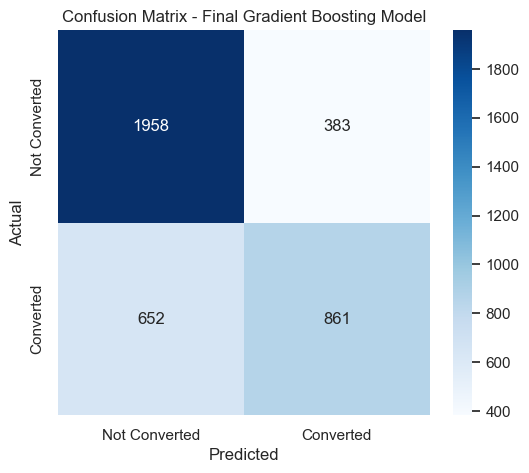

In [61]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Converted", "Converted"],
    yticklabels=["Not Converted", "Converted"]
)

plt.title("Confusion Matrix - Final Gradient Boosting Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 26. ROC Curve

Evaluate the final classification model using the Receiver Operating Characteristic (ROC) curve.

The ROC curve shows the trade-off between the true positive rate and false positive rate across different classification thresholds.

The Area Under the Curve (ROC-AUC) summarizes the model's ability to distinguish converted and non-converted leads.

In [62]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

roc_auc = auc(fpr, tpr)

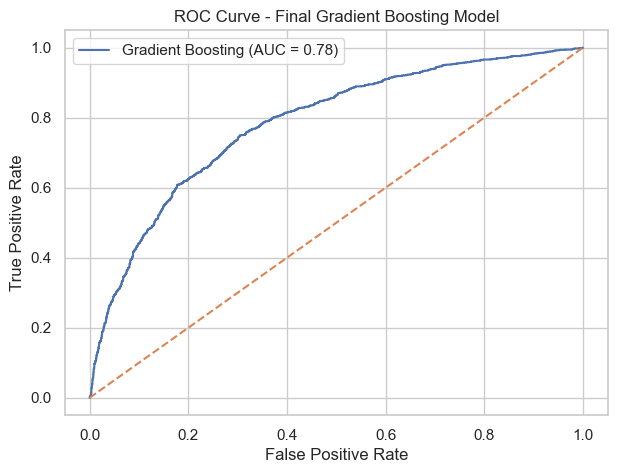

In [63]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve - Final Gradient Boosting Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 27. Feature Importance

Analyze the relative importance of the transformed features used by the final Gradient Boosting model.

Feature importance helps explain which lead characteristics contribute most to the model's predictive decisions.

In [64]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = final_model.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
14,numeric__Digital_Engagement_Score,0.50
58,categorical__Demo_Attended_No,0.14
1,numeric__Sales_Rep_Interactions,0.04
62,categorical__Trial_Started_No,0.04
61,categorical__Decision_Maker_Yes,0.04
59,categorical__Demo_Attended_Yes,0.03
11,numeric__Contact_Requests,0.03
63,categorical__Trial_Started_Yes,0.03
60,categorical__Decision_Maker_No,0.03
3,numeric__Days_Since_Last_Interaction,0.03


### 27.1 Top Feature Importances

Visualize the most important features contributing to the final model.

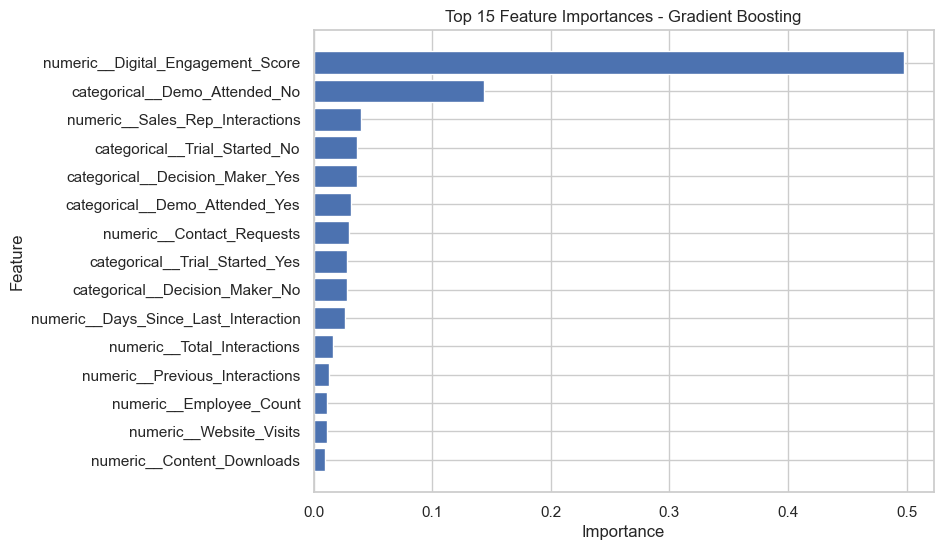

In [65]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 28. Permutation Feature Importance

Evaluate the importance of the original input features by measuring how much model performance decreases when each feature is randomly shuffled.

Permutation importance provides a more interpretable feature-level view because it evaluates the complete preprocessing and model pipeline using the original dataset columns.

In [66]:
from sklearn.inspection import permutation_importance

permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": permutation.importances_mean,
    "Importance_Std": permutation.importances_std
}).sort_values(
    "Importance_Mean",
    ascending=False
)

display(permutation_importance_df.head(15).round(4))

,Feature,Importance_Mean,Importance_Std
13,Demo_Attended,0.03,0.00
22,Digital_Engagement_Score,0.03,0.00
16,Decision_Maker,0.01,0.00
19,Trial_Started,0.01,0.00
7,Days_Since_Last_Interaction,0.00,0.00
17,Contact_Requests,0.00,0.00
5,Sales_Rep_Interactions,0.00,0.00
6,Previous_Interactions,0.00,0.00
2,Employee_Count,0.00,0.00
10,Email_Opens,0.00,0.00


## 29. Save Final Classification Pipeline

Save the fitted classification pipeline containing preprocessing and the final Gradient Boosting model.

The saved pipeline can later be loaded directly by the Streamlit application to make predictions on new leads.

In [67]:
import joblib

model_path = Path("../Models/classification_pipeline.joblib")

model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(final_model, model_path)

print(f"Final classification pipeline saved to: {model_path}")

Final classification pipeline saved to: ..\Models\classification_pipeline.joblib


## 30. Save Final Evaluation Metrics

Save the final test-set evaluation metrics separately so they can be displayed in the Streamlit application without retraining the model.

In [68]:
import json

metrics_path = Path("../Models/classification_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(
        {key: round(float(value), 4) for key, value in test_results.items()},
        f,
        indent=4
    )

print(f"Evaluation metrics saved to: {metrics_path}")

Evaluation metrics saved to: ..\Models\classification_metrics.json
